# AML s26 - Face Recognition with SVM

We use the **Olivetti Faces** dataset (AT&T) — 400 grayscale portraits of 40 people (10 photos each, 64×64 pixels). 
The task is to identify *which person* appears in an unseen photo.

Each image pixels is a feature (high-dimensional feature space with p=4096).
Idea: first compress them with **PCA** before handing them to an RBF SVM.

### Load libraries 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

### Load data

In [2]:
raw = np.load('olivetti_faces.npy')              # (400, 4096) uint8

X   = raw.astype('float32') / 255.0  # normalize to [0, 1]
n_people, n_per = 40, 10
y = np.repeat(np.arange(n_people), n_per)   # [0,0,...,1,1,...,39,39,...]

# shuffle consistently so classes are mixed before the train/test split
rng = np.random.default_rng(42)
perm = rng.permutation(len(X))
X, y = X[perm], y[perm]

img_size = int(X.shape[1] ** 0.5)   # 64
images   = X.reshape(-1, img_size, img_size)

print(f"Images : {X.shape[0]}")
print(f"Pixels : {X.shape[1]}  ({img_size}×{img_size})")
print(f"Classes: {len(np.unique(y))} people")

Images : 400
Pixels : 4096  (64×64)
Classes: 40 people


### Show examples of faces

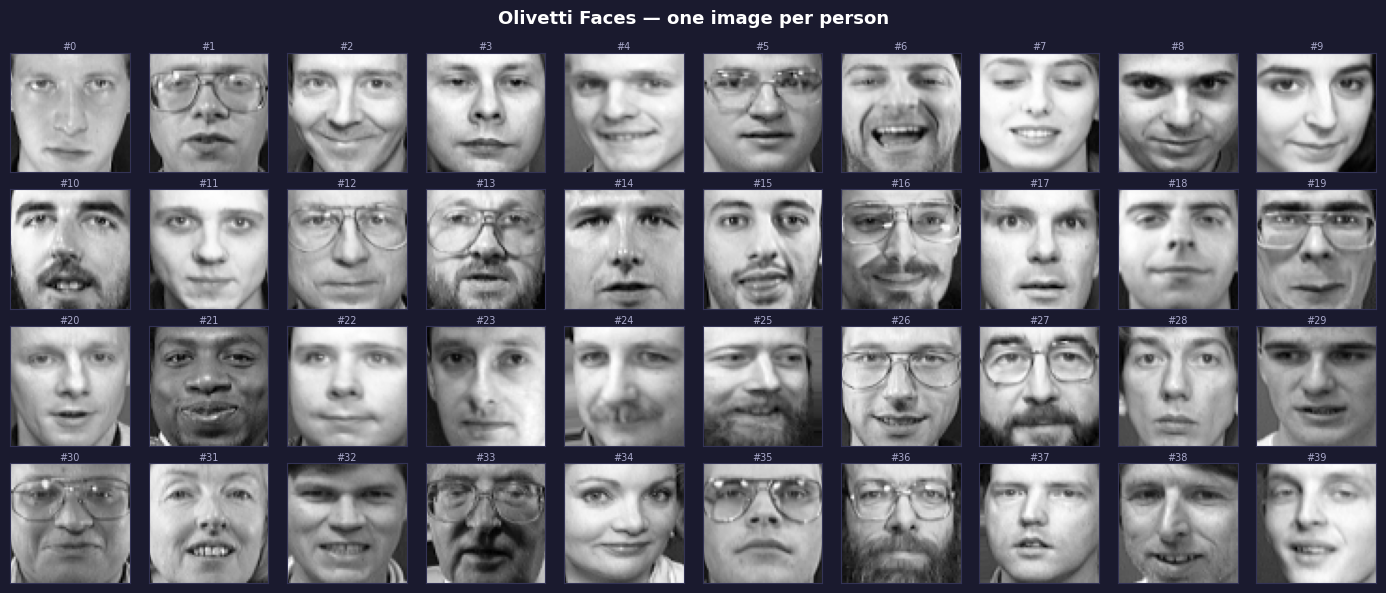

In [3]:
fig, axes = plt.subplots(4, 10, figsize=(14, 6), subplot_kw={'xticks': [], 'yticks': []})
fig.patch.set_facecolor('#1a1a2e')

# Show one image per person (first 40)
for person_id, ax in enumerate(axes.ravel()):
    idx = np.where(y == person_id)[0][0]
    ax.imshow(images[idx], cmap='gray')
    ax.set_title(f'#{person_id}', fontsize=7, color='#aaaacc', pad=2)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

fig.suptitle('Olivetti Faces — one image per person', fontsize=13, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

### Pipeline: PCA → SVM

PCA reduces 4096 raw pixels to a small number of **eigenfaces** — the principal directions of variation in the face space. The SVM then classifies in this compact representation.

We keep enough components to explain **95 % of the variance**.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=0.95, whiten=True, random_state=42)),
    ('svm',    SVC(kernel='rbf', C=5, gamma='scale', decision_function_shape='ovr')),
])

pipe.fit(X_train, y_train)

n_components = pipe['pca'].n_components_ 
test_acc  = pipe.score(X_test, y_test)
print(f"PCA components kept : {n_components}  (from 4096 pixels)")
print(f"Test accuracy       : {test_acc:.1%}")

PCA components kept : 108  (from 4096 pixels)
Test accuracy       : 97.0%


### Eigenfaces

The first few PCA components capture the most important facial structure — lighting, pose, expression

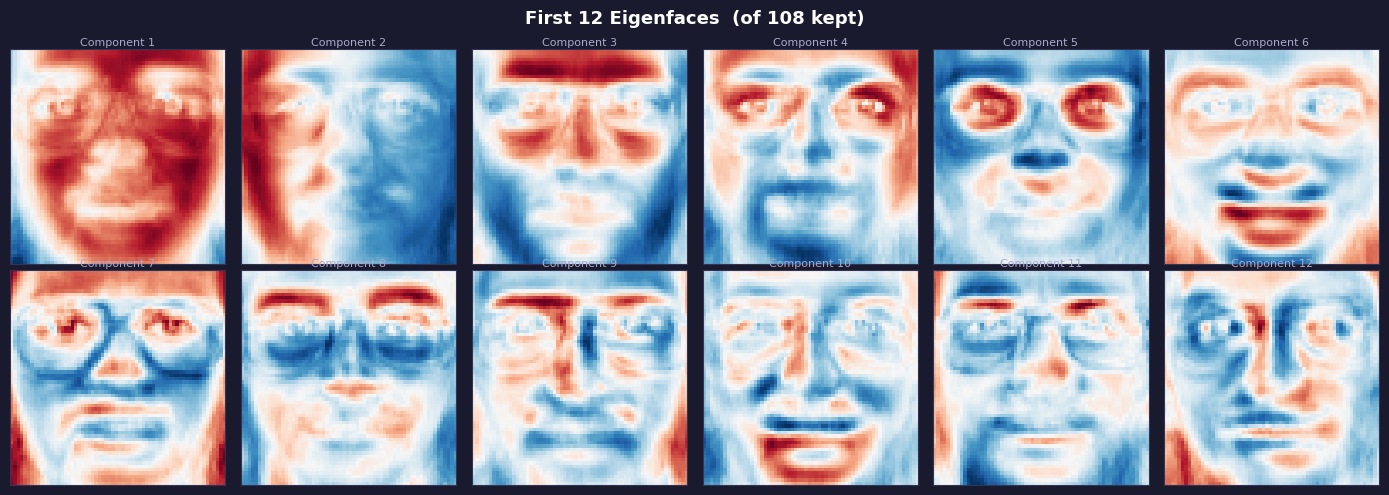

In [5]:
eigenfaces = pipe['pca'].components_.reshape(-1, 64, 64)
n_show = 12

fig, axes = plt.subplots(2, n_show // 2, figsize=(14, 5), subplot_kw={'xticks': [], 'yticks': []})
fig.patch.set_facecolor('#1a1a2e')

for i, ax in enumerate(axes.ravel()):
    ax.imshow(eigenfaces[i], cmap='RdBu_r')
    ax.set_title(f'Component {i+1}', fontsize=8, color='#aaaacc', pad=2)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

fig.suptitle(f'First {n_show} Eigenfaces  (of {n_components} kept)',  fontsize=13, fontweight='bold', color='white')
plt.tight_layout()

plt.show()

### Predictions on the test set

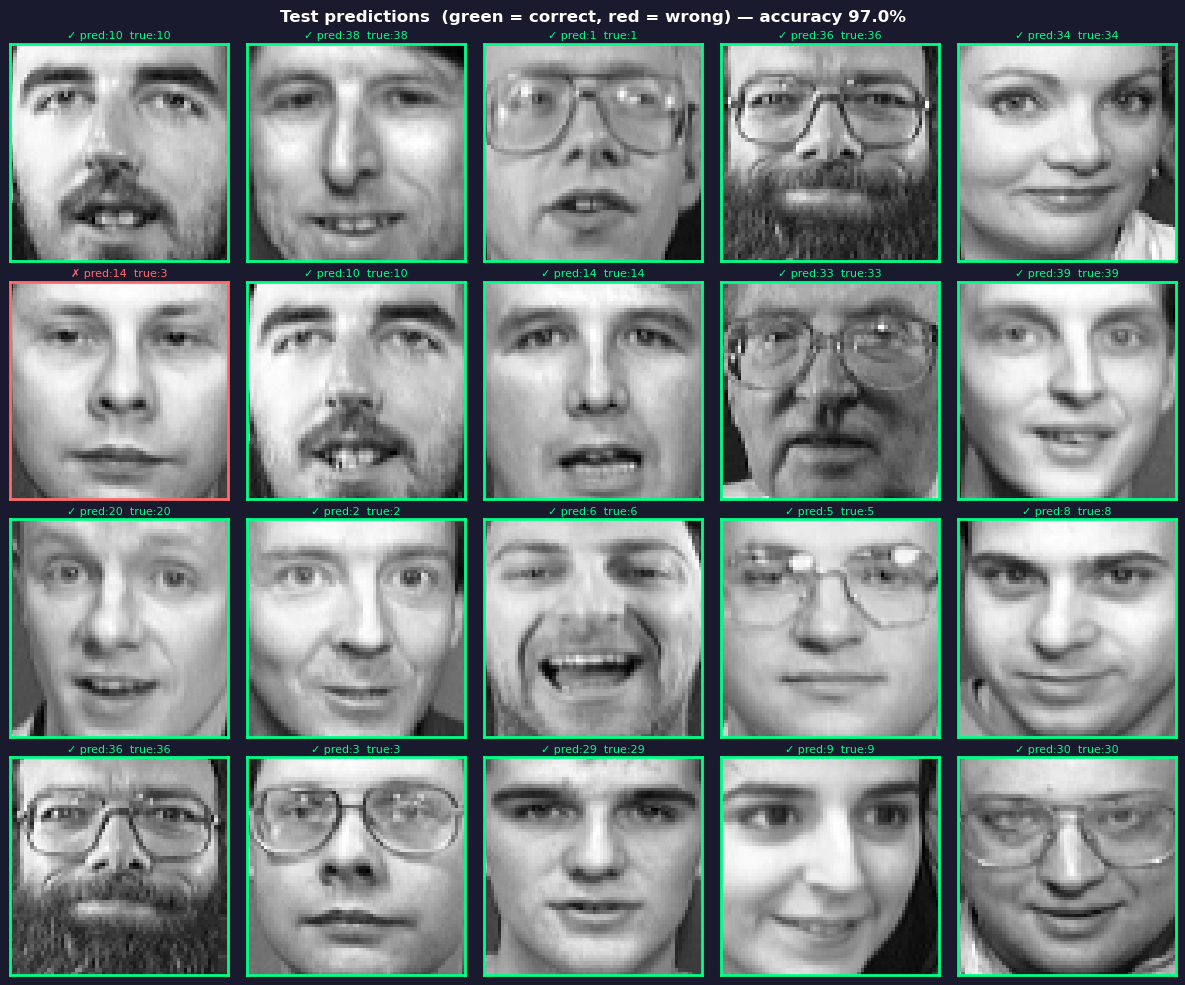

In [6]:
y_pred = pipe.predict(X_test)

n_show = 20
fig, axes = plt.subplots(4, 5, figsize=(12, 10), subplot_kw={'xticks': [], 'yticks': []})
fig.patch.set_facecolor('#1a1a2e')

rng = np.random.default_rng(0)
idxs = rng.choice(len(X_test), size=n_show, replace=False)

for ax, i in zip(axes.ravel(), idxs):
    correct = y_pred[i] == y_test[i]
    ax.imshow(X_test[i].reshape(64, 64), cmap='gray')
    color  = '#00ff88' if correct else '#ff6b6b'
    symbol = '✓' if correct else '✗'
    ax.set_title(f'{symbol} pred:{y_pred[i]}  true:{y_test[i]}',  fontsize=8, color=color, pad=3)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)

fig.suptitle(f'Test predictions  (green = correct, red = wrong) — accuracy {test_acc:.1%}',  fontsize=12, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

### Confusion matrix

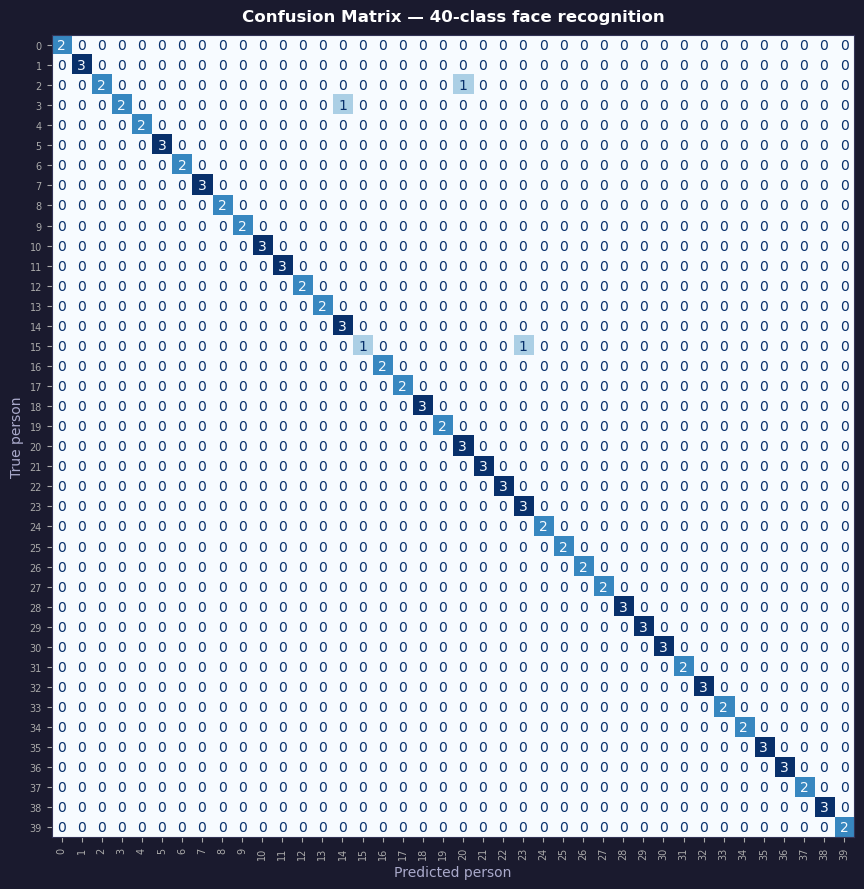

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3
           2       1.00      0.67      0.80         3
           3       1.00      0.67      0.80         3
           4       1.00      1.00      1.00         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       0.75      1.00      0.86         3
          15       1.00      0.50      0.67         2
          16       1.00      1.00      1.00         2
          17       1.00    

In [7]:
fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False, cmap='Blues',   xticks_rotation=90)

ax.set_title('Confusion Matrix — 40-class face recognition', fontsize=12, fontweight='bold', color='white', pad=10)
ax.tick_params(colors='#aaaaaa', labelsize=7)
ax.set_xlabel('Predicted person', color='#aaaacc', fontsize=10)
ax.set_ylabel('True person',      color='#aaaacc', fontsize=10)
for spine in ax.spines.values():
    spine.set_edgecolor('#333355')

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred))